Sedang memuat dan memproses gambar...
Total gambar berhasil dimuat: 4317
Bentuk Vektor Fitur (Jumlah Data, Fitur): (4317, 12288)

Jumlah Data Latih (Train): 3453
Jumlah Data Uji (Test)  : 864

Sedang melatih model Multi-Layer Perceptron (MLP)...
Iteration 1, loss = 2.61124004
Iteration 2, loss = 1.50638637
Iteration 3, loss = 1.39453902
Iteration 4, loss = 1.31520869
Iteration 5, loss = 1.26848141
Iteration 6, loss = 1.24959146
Iteration 7, loss = 1.19769246
Iteration 8, loss = 1.17327024
Iteration 9, loss = 1.16712688
Iteration 10, loss = 1.14690627
Iteration 11, loss = 1.15489040
Iteration 12, loss = 1.12230368
Iteration 13, loss = 1.09165340
Iteration 14, loss = 1.10162583
Iteration 15, loss = 1.10359452
Iteration 16, loss = 1.06826689
Iteration 17, loss = 1.08154264
Iteration 18, loss = 1.04900011
Iteration 19, loss = 1.05440293
Iteration 20, loss = 1.03479426
Iteration 21, loss = 1.03941751
Iteration 22, loss = 1.00169842
Iteration 23, loss = 0.96077947
Iteration 24, loss = 0.9525

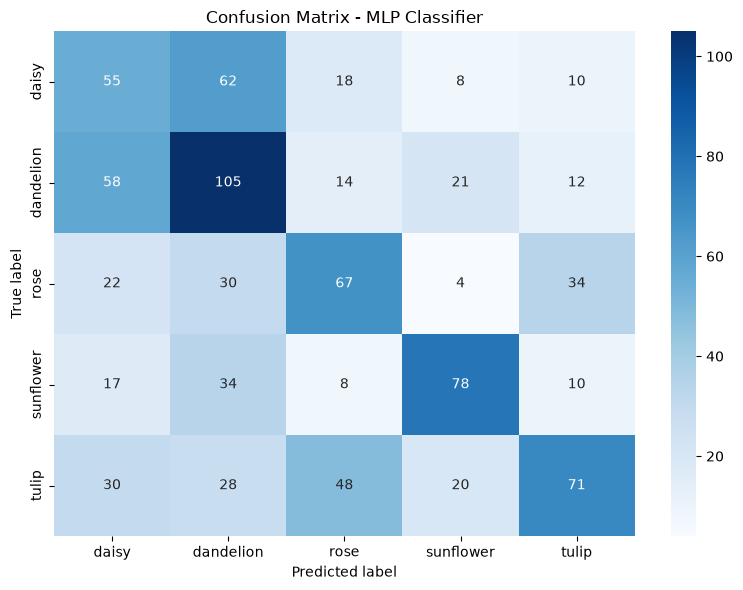

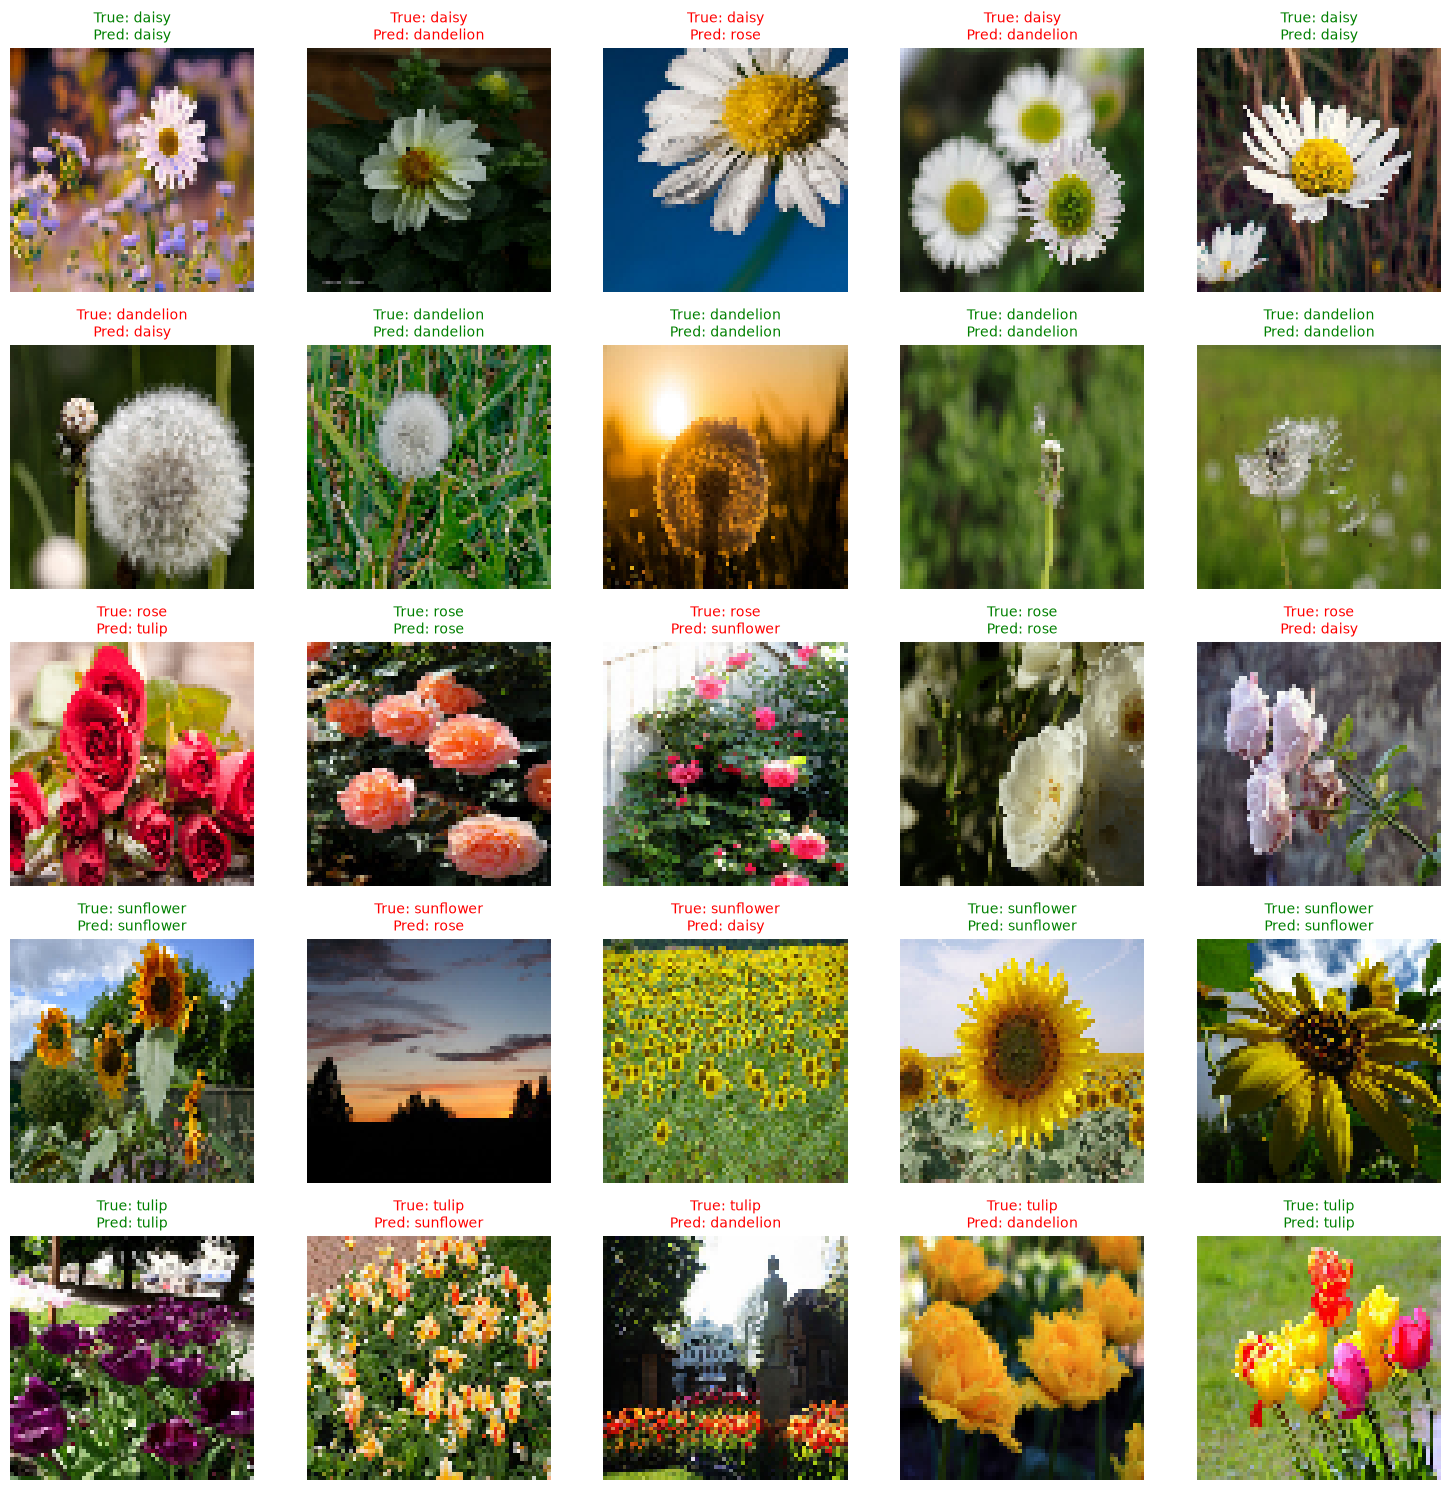

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ==========================================
# 1. PARAMETER & KONFIGURASI
# ==========================================
# Ganti dengan NIM Anda (Wajib sesuai instruksi soal)
NIM = 24146034  # <--- UBAH INI SESUAI NIM ANDA

# Nama folder dataset di VS Code Anda
DATASET_PATH = "flowers"

# Ukuran gambar yang diseragamkan (64x64 piksel agar proses training tidak terlalu berat)
IMG_SIZE = (64, 64)

# Daftar 5 kelas bunga sesuai dataset
CLASSES = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

# Set random seed untuk hasil numerik numpy yang konsisten
np.random.seed(NIM)

# ==========================================
# 2. LOAD DATASET & PREPROCESSING
# ==========================================
X = []
y = []

print("Sedang memuat dan memproses gambar...")

for label_idx, class_name in enumerate(CLASSES):
    folder_path = os.path.join(DATASET_PATH, class_name)

    # Cek apakah folder kelas ada
    if not os.path.exists(folder_path):
        print(f"Peringatan: Folder '{folder_path}' tidak ditemukan!")
        continue

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        # Baca gambar
        img = cv2.imread(img_path)

        if img is not None:
            # 1. Resize gambar ke 64x64
            img = cv2.resize(img, IMG_SIZE)

            # 2. Konversi warna dari BGR (OpenCV default) ke RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # 3. Flatten & Normalisasi
            X.append(img.flatten() / 255.0)
            y.append(label_idx)

X = np.array(X)
y = np.array(y)

print(f"Total gambar berhasil dimuat: {len(X)}")
print(f"Bentuk Vektor Fitur (Jumlah Data, Fitur): {X.shape}\n")

# ==========================================
# 3. SPLIT DATASET (80% Train, 20% Test)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=NIM,
    stratify=y
)

print(f"Jumlah Data Latih (Train): {len(X_train)}")
print(f"Jumlah Data Uji (Test)  : {len(X_test)}\n")

# ==========================================
# 4. TRAINING MODEL MLP (Multilayer Perceptron)
# ==========================================
print("Sedang melatih model Multi-Layer Perceptron (MLP)...")

model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=NIM,
    verbose=True
)

model.fit(X_train, y_train)
print("Pelatihan model selesai!\n")

# ==========================================
# 5. EVALUASI MODEL
# ==========================================
y_pred = model.predict(X_test)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test,
    y_pred,
    target_names=CLASSES,
    digits=4
))

# ==========================================
# CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.title("Confusion Matrix - MLP Classifier")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

# ==========================================
# 6. VISUALISASI 25 GAMBAR PREDIKSI
# ==========================================
fig, axes = plt.subplots(5, 5, figsize=(15, 15))

for i, class_name in enumerate(CLASSES):
    # Cari indeks data uji yang memiliki kelas ini
    indices = np.where(y_test == i)[0]

    # Pilih 5 gambar secara acak
    selected_indices = np.random.choice(indices, 5, replace=False)

    for j, idx in enumerate(selected_indices):
        img_reshaped = X_test[idx].reshape(IMG_SIZE[0], IMG_SIZE[1], 3)

        actual_label = CLASSES[y_test[idx]]
        pred_label = CLASSES[y_pred[idx]]

        ax = axes[i, j]
        ax.imshow(img_reshaped)
        ax.axis('off')

        # Warna hijau jika benar, merah jika salah
        color = 'green' if actual_label == pred_label else 'red'

        ax.set_title(
            f"True: {actual_label}\nPred: {pred_label}",
            color=color,
            fontsize=10
        )

plt.tight_layout()
plt.show()